# master_12_07

Notebook version of the optimized PhoBERT ABSA training script.

This version is tuned from the latest training logs and keeps the best parts of the 09/07 runs while improving class imbalance handling and validation stability.

In [5]:
from __future__ import annotations

import json
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")


@dataclass
class Config:
    model_name: str = "vinai/phobert-base-v2"
    data_file: str = "labeled_results_all_v6.json"
    output_dir: str = "."
    seed: int = 42
    max_len: int = 256
    batch_size: int = 32
    epochs: int = 20
    max_lr: float = 1.5e-5
    weight_decay: float = 0.05
    layer_decay: float = 0.9
    warmup_ratio: float = 0.1
    num_workers: int = 0
    label_smoothing: float = 0.08
    atmosphere_loss_scale: float = 1.35  # Đã tăng lên để chú trọng nhãn Atmosphere
    food_loss_scale: float = 1.05
    dropout_projection: float = 0.35     # Tăng để giảm Overfitting
    dropout_multisample: Tuple[float, float, float] = (0.10, 0.20, 0.30)
    hidden_projection_size: int = 256
    sampler_clip_min: float = 0.25
    sampler_clip_max: float = 8.0        # Tăng lên 8.0 để bốc nhiều mẫu thiểu số hơn


ASPECTS = ["Food quality", "Price", "Service quality", "Atmosphere"]
CLASS_NAMES = ["Negative", "Neutral", "Positive"]


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def map_label(value: float) -> int:
    if value == 0.0:
        return 0
    if value == 0.5:
        return 1
    if value == 1.0:
        return 2
    return 1


def find_data_file(config: Config) -> Path:
    base_dir = Path.cwd()
    candidates = [
        base_dir / config.data_file,
        base_dir.parent / config.data_file,
        Path(config.data_file),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Cannot find data file: {config.data_file}")


def load_dataframe(data_path: Path) -> pd.DataFrame:
    with data_path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    processed: List[Dict[str, int | str]] = []
    for item in raw_data:
        text = item["original_data"]["textTranslated"]
        labels = {entry["name"]: map_label(entry["value"]) for entry in item["labels"]}
        processed.append(
            {
                "text": text,
                "Food quality": labels.get("Food quality", 1),
                "Price": labels.get("Price", 1),
                "Service quality": labels.get("Service quality", 1),
                "Atmosphere": labels.get("Atmosphere", 1),
            }
        )

    df = pd.DataFrame(processed)
    df["stratify_key"] = df[ASPECTS].astype(str).agg("_".join, axis=1)
    return df


def safe_split(df: pd.DataFrame, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    stratify_key = df["stratify_key"]
    if stratify_key.value_counts().min() < 2:
        stratify_key = df["Atmosphere"].astype(str)
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=seed,
        stratify=stratify_key,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


class RestaurantReviewDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer: AutoTokenizer, max_len: int):
        self.texts = df["text"].values
        self.labels = df[ASPECTS].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        encoding = self.tokenizer(
            str(self.texts[index]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[index], dtype=torch.long),
        }


# ================== MỚI: FOCAL LOSS ==================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction='none')

    def forward(self, input, target):
        ce_loss = self.ce(input, target)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()
# =======================================================


# ====== MỚI: MÔ HÌNH VỚI ASPECT-SPECIFIC ATTENTION ======
class PhoBertABSA(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, n_aspects: int = 4,
                 hidden_projection_size: int = 256, dropout_projection: float = 0.35,
                 dropout_multisample: Tuple[float, float, float] = (0.10, 0.20, 0.30)):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size

        # Attention riêng cho từng khía cạnh
        self.aspect_attentions = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.Tanh(),
                nn.Linear(hidden_size, 1)
            ) for _ in range(n_aspects)
        ])

        self.aspect_projections = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_size * 2, hidden_projection_size),
                    nn.LayerNorm(hidden_projection_size),
                    nn.GELU(),
                    nn.Dropout(dropout_projection),
                )
                for _ in range(n_aspects)
            ]
        )

        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifiers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_projection_size, n_classes)) for _ in range(n_aspects)]
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> List[torch.Tensor]:
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state # [batch_size, seq_len, hidden_size]

        cls_pooled = last_hidden[:, 0, :] # [batch_size, hidden_size]
        mask = attention_mask.unsqueeze(-1).float() # [batch_size, seq_len, 1]

        logits: List[torch.Tensor] = []
        for aspect_idx in range(len(self.aspect_projections)):
            # Tính attention cho từng aspect
            attn_weights = self.aspect_attentions[aspect_idx](last_hidden)
            attn_weights = attn_weights.masked_fill(mask == 0, torch.finfo(attn_weights.dtype).min)
            attn_weights = F.softmax(attn_weights, dim=1)

            # Trích xuất đặc trưng của aspect đó từ câu
            aspect_pooled = torch.sum(attn_weights * last_hidden, dim=1)

            # Gộp với thông tin tổng thể của [CLS]
            fused = torch.cat([cls_pooled, aspect_pooled], dim=-1)

            aspect_repr = self.aspect_projections[aspect_idx](fused)
            stacked = torch.stack(
                [self.classifiers[aspect_idx](drop(aspect_repr)) for drop in self.dropouts],
                dim=0,
            )
            logits.append(stacked.mean(dim=0))

        return logits
# =======================================================


def build_class_weights(train_df: pd.DataFrame, config: Config, device: torch.device) -> List[torch.Tensor]:
    weights = []
    for aspect in ASPECTS:
        classes = np.unique(train_df[aspect].values)
        aspect_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df[aspect].values)
        aspect_weights = np.clip(aspect_weights, config.sampler_clip_min, config.sampler_clip_max)
        weights.append(torch.tensor(aspect_weights, dtype=torch.float32, device=device))
    return weights


def build_sample_weights(train_df: pd.DataFrame, class_weights: List[torch.Tensor]) -> np.ndarray:
    weights_by_aspect = [cw.detach().cpu().numpy() for cw in class_weights]
    sample_weights = []
    for _, row in train_df.iterrows():
        per_aspect = [weights_by_aspect[i][int(row[aspect])] for i, aspect in enumerate(ASPECTS)]
        sample_weight = float(np.mean(per_aspect))
        sample_weights.append(sample_weight)
    sample_weights = np.array(sample_weights, dtype=np.float64)
    # Đồng bộ với config
    sample_weights = np.clip(sample_weights, 0.25, 8.0)
    return sample_weights


def build_optimizer(model: nn.Module, config: Config) -> AdamW:
    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = []

    # Đã cập nhật lại params phần classification head
    head_params = list(model.classifiers.parameters()) + \
                  list(model.aspect_projections.parameters()) + \
                  list(model.aspect_attentions.parameters())
    param_groups.append({"params": head_params, "lr": config.max_lr})

    if hasattr(model.phobert, "encoder") and hasattr(model.phobert.encoder, "layer"):
        for layer_idx in range(len(model.phobert.encoder.layer) - 1, -1, -1):
            layer_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) - layer_idx))
            layer = model.phobert.encoder.layer[layer_idx]
            decay_params = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
            nodecay_params = [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)]
            if decay_params:
                param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": layer_lr})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": layer_lr})

    if hasattr(model.phobert, "embeddings"):
        embed_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) + 1))
        decay_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
        nodecay_params = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
        if decay_params:
            param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": embed_lr})
        if nodecay_params:
            param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": embed_lr})

    return AdamW(param_groups)


def make_loss_fns(class_weights: List[torch.Tensor], config: Config, device: torch.device) -> List[nn.Module]:
    losses: List[nn.Module] = []
    aspect_scales = {
        "Food quality": config.food_loss_scale,
        "Price": 1.0,
        "Service quality": 1.0,
        "Atmosphere": config.atmosphere_loss_scale,
    }
    for aspect_idx, aspect in enumerate(ASPECTS):
        # Đã thay bằng Focal Loss
        losses.append(
            FocalLoss(
                weight=class_weights[aspect_idx],
                gamma=2.0,
                label_smoothing=config.label_smoothing,
            ).to(device)
        )
    return losses, aspect_scales


@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fns: List[nn.Module], aspect_scales: Dict[str, float], device: torch.device):
    model.eval()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Validation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = 0.0
            for aspect_idx, aspect in enumerate(ASPECTS):
                loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], labels[:, aspect_idx])

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].cpu().tolist())

    per_aspect = {}
    confusion = {}
    recalls = []
    for aspect in ASPECTS:
        preds = np.array(all_preds[aspect])
        targets = np.array(all_targets[aspect])
        cm = confusion_matrix(targets, preds, labels=[0, 1, 2])
        confusion[aspect] = cm
        per_class_recall = np.diag(cm) / np.clip(cm.sum(axis=1), 1, None)
        recalls.append(float(per_class_recall.min()))
        per_aspect[aspect] = {
            "accuracy": float((preds == targets).mean()),
            "macro_f1": float(f1_score(targets, preds, average="macro", zero_division=0)),
            "per_class_recall": per_class_recall.tolist(),
        }

    all_targets_flat = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    all_preds_flat = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    overall_accuracy = float((all_preds_flat == all_targets_flat).mean())
    overall_macro_f1 = float(f1_score(all_targets_flat, all_preds_flat, average="macro", zero_division=0))
    mean_aspect_macro_f1 = float(np.mean([per_aspect[a]["macro_f1"] for a in ASPECTS]))
    worst_class_recall = float(np.min(recalls))

    score = 0.5 * overall_macro_f1 + 0.35 * mean_aspect_macro_f1 + 0.15 * worst_class_recall

    return {
        "loss": total_loss / max(len(data_loader), 1),
        "overall_accuracy": overall_accuracy,
        "overall_macro_f1": overall_macro_f1,
        "mean_aspect_macro_f1": mean_aspect_macro_f1,
        "worst_class_recall": worst_class_recall,
        "score": score,
        "per_aspect": per_aspect,
        "confusion": confusion,
        "all_preds": all_preds,
        "all_targets": all_targets,
    }


def train_one_epoch(model: nn.Module, data_loader: DataLoader, loss_fns: List[nn.Module], aspect_scales: Dict[str, float], optimizer: AdamW, scheduler, scaler, device: torch.device):
    model.train()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = 0.0
            for aspect_idx, aspect in enumerate(ASPECTS):
                loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], labels[:, aspect_idx])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.detach().cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].detach().cpu().tolist())

    flat_targets = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    flat_preds = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    return {
        "loss": total_loss / max(len(data_loader), 1),
        "accuracy": float((flat_targets == flat_preds).mean()),
        "macro_f1": float(f1_score(flat_targets, flat_preds, average="macro", zero_division=0)),
    }


def plot_confusion_matrices(confusion: Dict[str, np.ndarray], output_path: Path) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()
    for idx, aspect in enumerate(ASPECTS):
        matrix = confusion[aspect]
        ax = axes[idx]
        im = ax.imshow(matrix, cmap="Blues")
        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                ax.text(col_idx, row_idx, int(matrix[row_idx, col_idx]), ha="center", va="center", color="black")
        ax.set_xticks(range(len(CLASS_NAMES)))
        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(aspect)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


def main() -> None:
    config = Config()
    set_seed(config.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    output_dir = Path.cwd() / config.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    data_path = find_data_file(config)
    print(f"Using data file: {data_path}")
    print(f"Training on device: {device}")

    df = load_dataframe(data_path)
    train_df, val_df = safe_split(df, config.seed)

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    train_dataset = RestaurantReviewDataset(train_df, tokenizer, config.max_len)
    val_dataset = RestaurantReviewDataset(val_df, tokenizer, config.max_len)

    class_weights = build_class_weights(train_df, config, device)
    sample_weights = build_sample_weights(train_df, class_weights)
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    model = PhoBertABSA(
        model_name=config.model_name,
        hidden_projection_size=config.hidden_projection_size,
        dropout_projection=config.dropout_projection,
        dropout_multisample=config.dropout_multisample,
    ).to(device)

    optimizer = build_optimizer(model, config)
    total_steps = len(train_loader) * config.epochs
    warmup_steps = int(total_steps * config.warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    loss_fns, aspect_scales = make_loss_fns(class_weights, config, device)

    best_score = -1.0
    # Đổi tên file output v13 để không ghi đè log cũ của bạn
    best_path = output_dir / "best_phobert_absa_v13.pth"
    report_path = output_dir / "master_12_07_v13_report.json"
    confusion_path = output_dir / "master_12_07_v13_confusion.png"

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_mean_aspect_macro_f1": [],
        "val_worst_class_recall": [],
        "val_score": [],
    }

    for epoch in range(config.epochs):
        print(f"\nEpoch {epoch + 1}/{config.epochs} | lr={optimizer.param_groups[0]['lr']:.2e}")
        train_metrics = train_one_epoch(model, train_loader, loss_fns, aspect_scales, optimizer, scheduler, scaler, device)
        val_metrics = evaluate(model, val_loader, loss_fns, aspect_scales, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["overall_accuracy"])
        history["val_macro_f1"].append(val_metrics["overall_macro_f1"])
        history["val_mean_aspect_macro_f1"].append(val_metrics["mean_aspect_macro_f1"])
        history["val_worst_class_recall"].append(val_metrics["worst_class_recall"])
        history["val_score"].append(val_metrics["score"])

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['overall_accuracy']:.4f} | Val F1: {val_metrics['overall_macro_f1']:.4f} | Val Score: {val_metrics['score']:.4f}"
        )
        print(
            f"Val Mean Aspect F1: {val_metrics['mean_aspect_macro_f1']:.4f} | Val Worst Recall: {val_metrics['worst_class_recall']:.4f}"
        )
        for aspect in ASPECTS:
            aspect_metrics = val_metrics["per_aspect"][aspect]
            recalls = ", ".join(f"{value:.3f}" for value in aspect_metrics["per_class_recall"])
            print(
                f"  - {aspect}: acc={aspect_metrics['accuracy']:.4f} | f1={aspect_metrics['macro_f1']:.4f} | recall=[{recalls}]"
            )

        if val_metrics["score"] > best_score:
            best_score = val_metrics["score"]
            torch.save(model.state_dict(), best_path)
            plot_confusion_matrices(val_metrics["confusion"], confusion_path)
            best_report = {
                "config": asdict(config),
                "data_file": str(data_path),
                "best_score": best_score,
                "epoch": epoch + 1,
                "train_metrics": train_metrics,
                "val_metrics": {
                    key: value
                    for key, value in val_metrics.items()
                    if key not in {"confusion", "all_preds", "all_targets"}
                },
                "history": history,
            }
            with report_path.open("w", encoding="utf-8") as f:
                json.dump(best_report, f, ensure_ascii=False, indent=2)
            print(f"Saved best checkpoint to {best_path.name}")

    print("\nTraining complete.")
    print(f"Best score: {best_score:.4f}")
    print(f"Best checkpoint: {best_path}")
    print(f"Report: {report_path}")
    print(f"Confusion matrix: {confusion_path}")


if __name__ == "__main__":
    main()

Using data file: /content/labeled_results_all_v6.json
Training on device: cuda


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/20 | lr=0.00e+00


Validation: 100%|██████████| 140/140 [00:17<00:00,  8.03it/s]


...

Train Loss: 0.3667 | Train Acc: 0.9860 | Train F1: 0.9873
Val Loss: 1.1148 | Val Acc: 0.9331 | Val F1: 0.9036 | Val Score: 0.8701
Val Mean Aspect F1: 0.8888 | Val Worst Recall: 0.7152
  - Food quality: acc=0.9309 | f1=0.8800 | recall=[0.847, 0.856, 0.961]
  - Price: acc=0.9528 | f1=0.9135 | recall=[0.910, 0.955, 0.958]
  - Service quality: acc=0.9379 | f1=0.9172 | recall=[0.880, 0.921, 0.962]
  - Atmosphere: acc=0.9106 | f1=0.8443 | recall=[0.715, 0.909, 0.928]

Epoch 19/20 | lr=4.52e-07


Validation: 100%|██████████| 140/140 [00:17<00:00,  8.07it/s]


Train Loss: 0.3618 | Train Acc: 0.9863 | Train F1: 0.9877
Val Loss: 1.1122 | Val Acc: 0.9325 | Val F1: 0.9027 | Val Score: 0.8702
Val Mean Aspect F1: 0.8877 | Val Worst Recall: 0.7212
  - Food quality: acc=0.9303 | f1=0.8793 | recall=[0.855, 0.853, 0.960]
  - Price: acc=0.9524 | f1=0.9114 | recall=[0.914, 0.956, 0.950]
  - Service quality: acc=0.9374 | f1=0.9162 | recall=[0.880, 0.919, 0.962]
  - Atmosphere: acc=0.9099 | f1=0.8438 | recall=[0.721, 0.911, 0.924]

Epoch 20/20 | lr=1.14e-07


Validation: 100%|██████████| 140/140 [00:17<00:00,  8.14it/s]

Train Loss: 0.3603 | Train Acc: 0.9862 | Train F1: 0.9876
Val Loss: 1.1113 | Val Acc: 0.9323 | Val F1: 0.9024 | Val Score: 0.8699
Val Mean Aspect F1: 0.8873 | Val Worst Recall: 0.7212
  - Food quality: acc=0.9305 | f1=0.8795 | recall=[0.855, 0.853, 0.960]
  - Price: acc=0.9520 | f1=0.9105 | recall=[0.914, 0.956, 0.950]
  - Service quality: acc=0.9377 | f1=0.9164 | recall=[0.880, 0.919, 0.962]
  - Atmosphere: acc=0.9093 | f1=0.8428 | recall=[0.721, 0.909, 0.925]

Training complete.
Best score: 0.8852
Best checkpoint: /content/best_phobert_absa_v13.pth
Report: /content/master_12_07_v13_report.json
Confusion matrix: /content/master_12_07_v13_confusion.png


Đã lưu biểu đồ history tại: history_curves.png


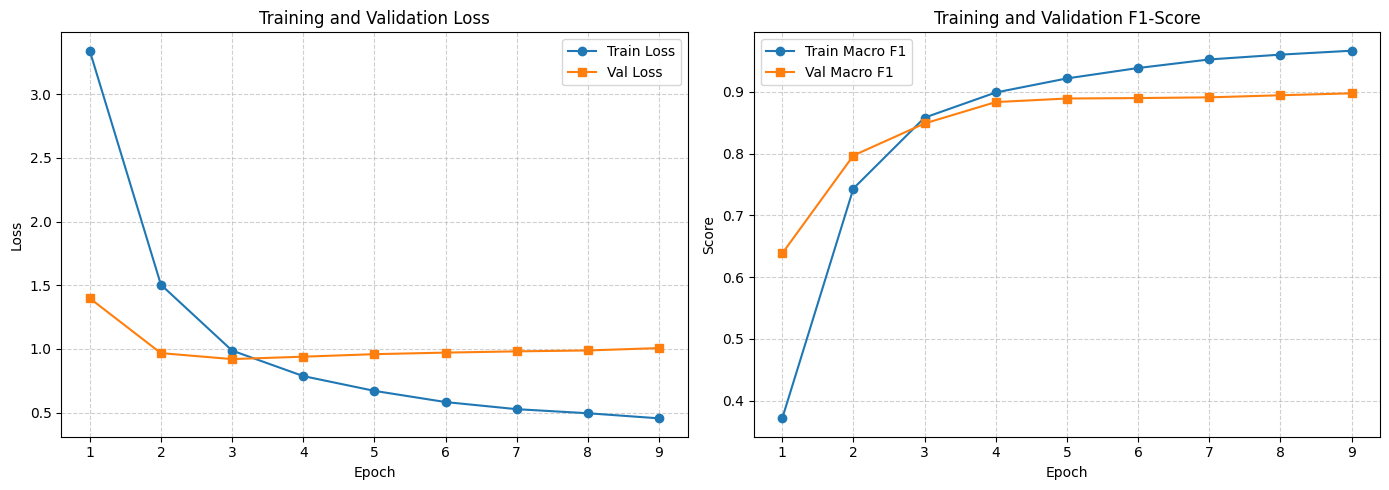


Đang nạp mô hình...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Nạp thành công trọng số từ best_phobert_absa_v13.pth
Đang chạy mô hình trên tập Validation để lấy dự đoán...


100%|██████████| 140/140 [01:09<00:00,  2.02it/s]



     BẢNG MA TRẬN NHẦM LẪN (THEO PHẦN TRĂM %)     

--- NHÃN: FOOD QUALITY ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            89.3%            9.6%             1.1%
Thực tế Neutral              9.8%           85.1%             5.1%
Thực tế Positive             0.5%            5.1%            94.4%

--- NHÃN: PRICE ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            95.7%            2.3%             2.0%
Thực tế Neutral              2.2%           94.7%             3.1%
Thực tế Positive             2.0%            2.7%            95.3%

--- NHÃN: SERVICE QUALITY ---
                 Dự đoán Negative Dự đoán Neutral Dự đoán Positive
Thực tế Negative            88.9%           10.3%             0.8%
Thực tế Neutral              3.5%           93.1%             3.4%
Thực tế Positive             0.6%            4.1%            95.3%

--- NHÃN: ATMOSPHERE ---
                 Dự đoán Negative Dự đ

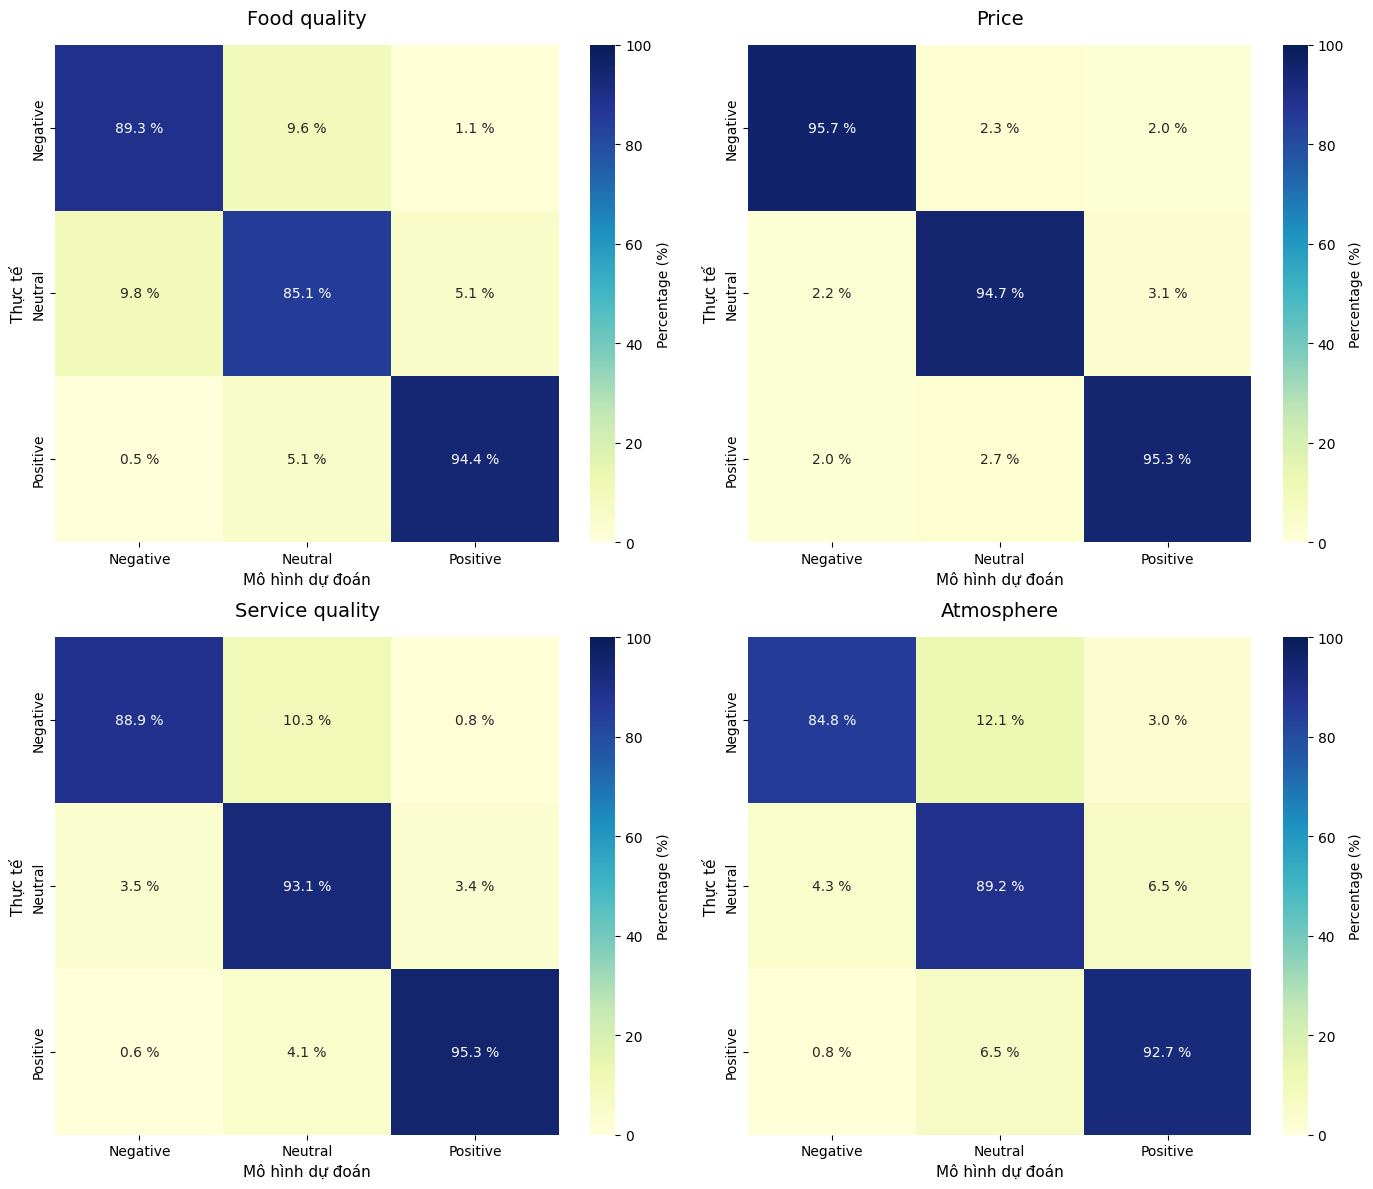

In [6]:
import json
import warnings
from pathlib import Path
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")

# ================= CÁC THÔNG SỐ CẦN KHỚP VỚI LÚC TRAIN =================
MODEL_NAME = "vinai/phobert-base-v2"
DATA_FILE = "labeled_results_all_v6.json"
CHECKPOINT_PATH = "best_phobert_absa_v13.pth"
REPORT_PATH = "master_12_07_v13_report.json"

ASPECTS = ["Food quality", "Price", "Service quality", "Atmosphere"]
CLASS_NAMES = ["Negative", "Neutral", "Positive"]
MAX_LEN = 256
BATCH_SIZE = 32
# =======================================================================

# Khai báo lại Model (để có thể load weights)
class PhoBertABSA(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, n_aspects: int = 4,
                 hidden_projection_size: int = 256, dropout_projection: float = 0.35,
                 dropout_multisample: Tuple[float, float, float] = (0.10, 0.20, 0.30)):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size

        self.aspect_attentions = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.Tanh(), nn.Linear(hidden_size, 1))
            for _ in range(n_aspects)
        ])

        self.aspect_projections = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_projection_size),
                nn.LayerNorm(hidden_projection_size),
                nn.GELU(),
                nn.Dropout(dropout_projection),
            ) for _ in range(n_aspects)
        ])

        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifiers = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden_projection_size, n_classes)) for _ in range(n_aspects)
        ])

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> List[torch.Tensor]:
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state
        cls_pooled = last_hidden[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()

        logits: List[torch.Tensor] = []
        for aspect_idx in range(len(self.aspect_projections)):
            attn_weights = self.aspect_attentions[aspect_idx](last_hidden)
            attn_weights = attn_weights.masked_fill(mask == 0, -1e9)
            attn_weights = F.softmax(attn_weights, dim=1)
            aspect_pooled = torch.sum(attn_weights * last_hidden, dim=1)
            fused = torch.cat([cls_pooled, aspect_pooled], dim=-1)
            aspect_repr = self.aspect_projections[aspect_idx](fused)
            stacked = torch.stack([self.classifiers[aspect_idx](drop(aspect_repr)) for drop in self.dropouts], dim=0)
            logits.append(stacked.mean(dim=0))
        return logits

# Hàm load data y hệt lúc train để lấy đúng tập Validation
def map_label(value: float) -> int:
    if value == 0.0: return 0
    if value == 0.5: return 1
    if value == 1.0: return 2
    return 1

class DatasetEval(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["text"].values
        self.labels = df[ASPECTS].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), add_special_tokens=True, max_length=self.max_len,
                             padding="max_length", truncation=True, return_attention_mask=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].flatten(), "attention_mask": enc["attention_mask"].flatten(),
                "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

def get_val_loader():
    with open(DATA_FILE, "r", encoding="utf-8") as f:
        raw_data = json.load(f)
    processed = []
    for item in raw_data:
        labels = {entry["name"]: map_label(entry["value"]) for entry in item["labels"]}
        processed.append({
            "text": item["original_data"]["textTranslated"],
            "Food quality": labels.get("Food quality", 1),
            "Price": labels.get("Price", 1),
            "Service quality": labels.get("Service quality", 1),
            "Atmosphere": labels.get("Atmosphere", 1),
        })
    df = pd.DataFrame(processed)
    df["stratify_key"] = df[ASPECTS].astype(str).agg("_".join, axis=1)

    if df["stratify_key"].value_counts().min() < 2:
        stratify_key = df["Atmosphere"].astype(str)
    else:
        stratify_key = df["stratify_key"]

    _, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=stratify_key)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    val_dataset = DatasetEval(val_df.reset_index(drop=True), tokenizer, MAX_LEN)
    return DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


def plot_history(report_path: str):
    """Đọc JSON và vẽ biểu đồ Loss/F1"""
    try:
        with open(report_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        history = data["history"]
        epochs = range(1, len(history["train_loss"]) + 1)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Loss Chart
        ax1.plot(epochs, history["train_loss"], label='Train Loss', marker='o')
        ax1.plot(epochs, history["val_loss"], label='Val Loss', marker='s')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)

        # F1 Chart
        ax2.plot(epochs, history["train_macro_f1"], label='Train Macro F1', marker='o')
        ax2.plot(epochs, history["val_macro_f1"], label='Val Macro F1', marker='s')
        ax2.set_title('Training and Validation F1-Score')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Score')
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.savefig("history_curves.png", dpi=200)
        print("Đã lưu biểu đồ history tại: history_curves.png")
        plt.show()
    except Exception as e:
        print(f"Không thể vẽ biểu đồ History (lỗi đọc JSON): {e}")


def plot_and_print_percentage_cm(model, val_loader, device):
    """Chạy mô hình, tính ma trận nhầm lẫn phần trăm (Vẽ ảnh + In bảng)"""
    model.eval()
    all_preds = {aspect: [] for aspect in ASPECTS}
    all_targets = {aspect: [] for aspect in ASPECTS}

    print("Đang chạy mô hình trên tập Validation để lấy dự đoán...")
    with torch.no_grad():
        for batch in tqdm(val_loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"]

            logits = model(input_ids, attention_mask)

            for aspect_idx, aspect in enumerate(ASPECTS):
                preds = torch.argmax(logits[aspect_idx], dim=1).cpu().tolist()
                all_preds[aspect].extend(preds)
                all_targets[aspect].extend(labels[:, aspect_idx].tolist())

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    print("\n" + "="*50)
    print(" BẢNG MA TRẬN NHẦM LẪN (THEO PHẦN TRĂM %)".center(50))
    print("="*50)

    for idx, aspect in enumerate(ASPECTS):
        # Tính Confusion Matrix gốc
        cm = confusion_matrix(all_targets[aspect], all_preds[aspect], labels=[0, 1, 2])

        # Chuyển đổi thành Phần Trăm theo hàng ngang (Row-wise percentage: Recall per class)
        row_sums = cm.sum(axis=1)[:, np.newaxis]
        row_sums[row_sums == 0] = 1 # Tránh lỗi chia cho 0
        cm_pct = (cm.astype(float) / row_sums) * 100

        # === 1. IN RA BẢNG (TEXT) ===
        print(f"\n--- NHÃN: {aspect.upper()} ---")
        df_cm = pd.DataFrame(
            cm_pct,
            index=[f"Thực tế {c}" for c in CLASS_NAMES],
            columns=[f"Dự đoán {c}" for c in CLASS_NAMES]
        )
        # Format bảng chỉ lấy 1 chữ số thập phân, có dấu %
        print(df_cm.map(lambda x: f"{x:.1f}%"))

        # === 2. VẼ HEATMAP (ẢNH) ===
        ax = axes[idx]
        sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    cbar_kws={'label': 'Percentage (%)'}, vmin=0, vmax=100)

        # Thêm ký hiệu % vào từng ô text trong heatmap
        for t in ax.texts: t.set_text(t.get_text() + " %")

        ax.set_title(f"{aspect}", fontsize=14, pad=15)
        ax.set_xlabel("Mô hình dự đoán", fontsize=11)
        ax.set_ylabel("Thực tế", fontsize=11)

    plt.tight_layout()
    plt.savefig("percentage_confusion_matrix.png", dpi=200, bbox_inches="tight")
    print("\nĐã lưu ảnh Ma trận nhầm lẫn phần trăm tại: percentage_confusion_matrix.png")
    plt.show()

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Vẽ biểu đồ Loss từ file JSON Report
    plot_history(REPORT_PATH)

    # 2. Khởi tạo và Load trọng số mô hình
    print("\nĐang nạp mô hình...")
    model = PhoBertABSA(MODEL_NAME).to(device)
    try:
        model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        print(f"Nạp thành công trọng số từ {CHECKPOINT_PATH}")
    except Exception as e:
        print(f"Lỗi nạp weights. Hãy kiểm tra lại đường dẫn CHECKPOINT_PATH. Lỗi: {e}")
        return

    # 3. Nạp Data Validation
    val_loader = get_val_loader()

    # 4. Phân tích & Xuất Ma trận
    plot_and_print_percentage_cm(model, val_loader, device)

if __name__ == "__main__":
    main()